# Market Data Analysis for Suspicious Patterns
### Makarova Vera
### November 2025
#### An investigative analysis of ETH/BTC market activity to uncover suspicious trading behaviours

In [1]:
import pandas as pd
import numpy as np
import ast
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
import ast

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,5)

## Loading data
**Goal:** Extract clean numeric time series for plotting and analysis.

In [2]:
TRADES_CSV = "/kaggle/input/suspicious-market-patterns-challenge/eth-btc-trades.csv"
trades = pd.read_csv(TRADES_CSV, parse_dates=["timestamp"])

# quick checks
print("trades shape:", trades.shape)
print(trades.head())
print(trades.info()) #ensuring timestamps are real datetime objects

trades shape: (845, 4)
                  timestamp     price       size  side
0 2025-09-01 00:02:57+00:00  0.040800   0.000441  SELL
1 2025-09-01 00:02:57+00:00  0.040700   0.002478  SELL
2 2025-09-01 00:02:57+00:00  0.040700   0.020152  SELL
3 2025-09-01 00:02:57+00:00  0.040600   0.002460  SELL
4 2025-09-01 00:03:14+00:00  0.040812  91.455503   BUY
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 845 entries, 0 to 844
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   timestamp  845 non-null    datetime64[ns, UTC]
 1   price      845 non-null    float64            
 2   size       845 non-null    float64            
 3   side       845 non-null    object             
dtypes: datetime64[ns, UTC](1), float64(2), object(1)
memory usage: 26.5+ KB
None


In [3]:
ORDERBOOK_CSV = "/kaggle/input/suspicious-market-patterns-challenge/eth-btc-orderbooks.csv"
orderbooks = pd.read_csv(ORDERBOOK_CSV, parse_dates=["timestamp"])

# Convert string representations into lists
orderbooks['asks'] = orderbooks['asks'].apply(ast.literal_eval)
orderbooks['bids'] = orderbooks['bids'].apply(ast.literal_eval)

# quick checks
print("orderbooks shape:", orderbooks.shape)
print(orderbooks.head()) #making sure asks and bids are Python objects, not strings
print(orderbooks.info())

orderbooks shape: (188, 3)
                            timestamp  \
0 2025-09-01 00:13:09.511132300+00:00   
1 2025-09-01 00:31:23.134173200+00:00   
2 2025-09-01 00:49:37.173137500+00:00   
3 2025-09-01 01:07:51.274078600+00:00   
4    2025-09-01 01:26:07.248503+00:00   

                                                asks  \
0  [{'price': 0.04100829, 'size': 0.02288708}, {'...   
1  [{'price': 0.04097411, 'size': 0.02047798}, {'...   
2  [{'price': 0.04091134, 'size': 0.02229217}, {'...   
3  [{'price': 0.04103079, 'size': 0.07205901}, {'...   
4  [{'price': 0.04100837, 'size': 0.02019721}, {'...   

                                                bids  
0  [{'price': 0.0405, 'size': 0.00249086}, {'pric...  
1  [{'price': 0.0405, 'size': 0.00249086}, {'pric...  
2  [{'price': 0.0405, 'size': 0.00249086}, {'pric...  
3  [{'price': 0.0405, 'size': 0.00249086}, {'pric...  
4  [{'price': 0.0405, 'size': 0.00249086}, {'pric...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entri

# Stage 1: Micro-level analysis


## Key features of each orderbook snapshot
**Goal:** Summarize the entire orderbook into a few interpretable signals that reflect the state of supply and demand at each point in time.

I will be using these metrics because they capture the essential forces that move prices:
1. top_ask_price / top_bid_price (best sell and buy)

2. spread = ask - bid

3. midprice = (ask + bid)/2

4. bid_depth / ask_depth (total liquidity on each side)

5. imbalance = (bid_depth - ask_depth) / (bid_depth + ask_depth)

In [4]:
def summarize_orderbook(row):
    bids = sorted(row['bids'], key=lambda x: x['price'], reverse=True)
    asks = sorted(row['asks'], key=lambda x: x['price'])

    top_bid = bids[0]['price'] if bids else None
    top_ask = asks[0]['price'] if asks else None
    spread = top_ask - top_bid if (top_bid and top_ask) else None
    mid = (top_ask + top_bid)/2 if (top_bid and top_ask) else None
    
    bid_depth = sum([b['size'] for b in bids])
    ask_depth = sum([a['size'] for a in asks])
    imbalance = (bid_depth - ask_depth) / (bid_depth + ask_depth) if (bid_depth + ask_depth) != 0 else 0

    return pd.Series({
        'top_bid': top_bid,
        'top_ask': top_ask,
        'spread': spread,
        'midprice': mid,
        'bid_depth': bid_depth,
        'ask_depth': ask_depth,
        'imbalance': imbalance
    })

order_summaries = orderbooks.apply(summarize_orderbook, axis=1)
orderbooks_features = pd.concat([orderbooks[['timestamp']], order_summaries], axis=1)

print(orderbooks_features)
print(orderbooks)

                              timestamp  top_bid   top_ask    spread  \
0   2025-09-01 00:13:09.511132300+00:00   0.0405  0.041008  0.000508   
1   2025-09-01 00:31:23.134173200+00:00   0.0405  0.040974  0.000474   
2   2025-09-01 00:49:37.173137500+00:00   0.0405  0.040911  0.000411   
3   2025-09-01 01:07:51.274078600+00:00   0.0405  0.041031  0.000531   
4      2025-09-01 01:26:07.248503+00:00   0.0405  0.041008  0.000508   
..                                  ...      ...       ...       ...   
183 2025-09-03 16:51:52.312995900+00:00   0.0396  0.039900  0.000300   
184 2025-09-03 17:29:00.608039700+00:00   0.0396  0.039900  0.000300   
185 2025-09-03 17:47:18.795398100+00:00   0.0396  0.039900  0.000300   
186 2025-09-03 19:55:17.638768700+00:00   0.0398  0.039900  0.000100   
187 2025-09-03 20:50:36.802878100+00:00   0.0398  0.039900  0.000100   

     midprice  bid_depth  ask_depth  imbalance  
0    0.040754   1.625534   0.335770   0.657605  
1    0.040737   1.625534   0.333361  

In [5]:
orderbooks_features.describe().T

,count,mean,std,min,25%,50%,75%,max
top_bid,188.0,0.039610,0.000593,0.038800,0.039006,0.039400,0.040400,0.040513
top_ask,188.0,0.039968,0.000688,0.039000,0.039288,0.039900,0.040671,0.041090
spread,188.0,0.000358,0.000171,0.000007,0.000213,0.000359,0.000531,0.000578
midprice,188.0,0.039789,0.000636,0.038900,0.039144,0.039675,0.040541,0.040802
bid_depth,188.0,1.531306,0.091990,1.425538,1.466017,1.507842,1.528932,1.798526
ask_depth,188.0,1.452942,14.565507,0.318646,0.348571,0.378867,0.399122,200.100935
imbalance,188.0,0.586098,0.124809,-0.983539,0.583872,0.593781,0.621140,0.659882


## Visualisations & initial observations
**Goal:** Provide preliminary qualitative anomaly observations


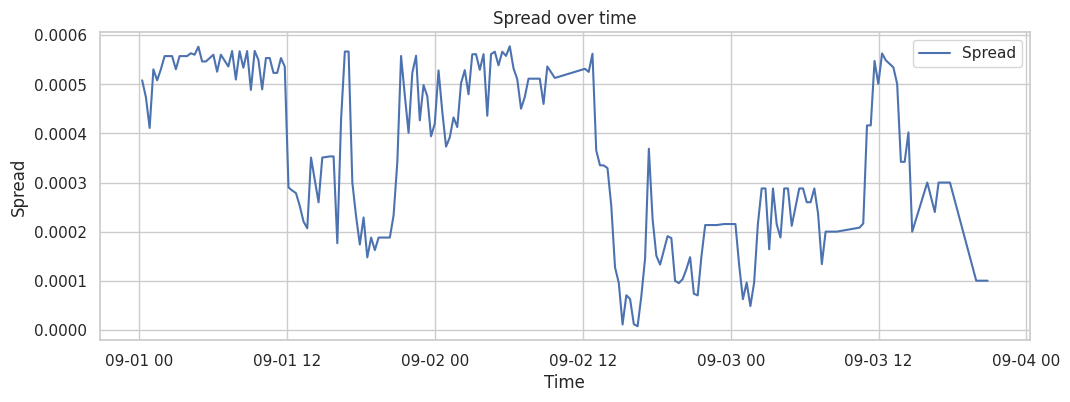

In [6]:
# 1. Spread over time
plt.figure(figsize=(12,4))
plt.plot(orderbooks_features['timestamp'], orderbooks_features['spread'], label='Spread')
plt.title('Spread over time')
plt.ylabel('Spread')
plt.xlabel('Time')
plt.legend()
plt.show()

Spread identifies liquidity stress. Now we look at the times when spread spikes upwards and when spread has unusually high values, to note potential points of liquidity disappearing, which may indicate potential market manipulation.

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


Found 4 spike up events
Found the following upward spikes ts:
49    2025-09-01 16:22:00.113146600+00:00
64    2025-09-01 21:14:09.411221300+00:00
121   2025-09-02 17:20:50.825163600+00:00
169   2025-09-03 11:03:15.525161200+00:00
Name: timestamp, dtype: datetime64[ns, UTC]
Spike threshold: 0.000160 (absolute change)


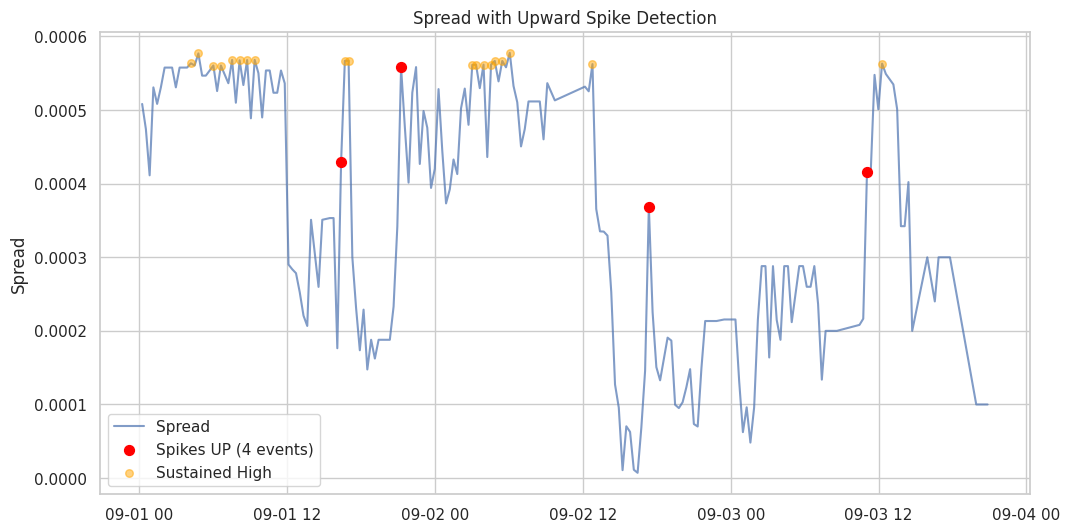

In [7]:
# Calculate the "spikiness" - how fast the spread is changing
orderbooks_features['spread_change'] = orderbooks_features['spread'].diff()  # Absolute change from previous point
orderbooks_features['spread_pct_change'] = (orderbooks_features['spread'].pct_change().abs() * 100)  # Percentage change

# Find spikes - sudden large changes
spike_threshold = orderbooks_features['spread_change'].quantile(0.98)  # Top 2% of changes
spikes = orderbooks_features[orderbooks_features['spread_change'] > spike_threshold]

print(f"Found {len(spikes)} spike up events")
print(f"Found the following upward spikes ts:\n{spikes['timestamp']}")
print(f"Spike threshold: {spike_threshold:.6f} (absolute change)")

# Plot with spikes marked
plt.figure(figsize=(12, 6))
plt.plot(orderbooks_features['timestamp'], orderbooks_features['spread'], 'b-', alpha=0.7, label='Spread')
plt.scatter(spikes['timestamp'], spikes['spread'], color='red', s=50, zorder=5, 
           label=f'Spikes UP ({len(spikes)} events)')

# Also mark where spread stays high for a while
high_spread_threshold = orderbooks_features['spread'].quantile(0.90)  # Top 10% values
sustained_high = orderbooks_features[orderbooks_features['spread'] > high_spread_threshold]
plt.scatter(sustained_high['timestamp'], sustained_high['spread'], color='orange', s=30, zorder=4,
           alpha=0.5, label='Sustained High')

plt.title('Spread with Upward Spike Detection')
plt.ylabel('Spread')
plt.legend()
plt.show()

### Spread Analysis Observations

**Time Period:** Sept 1-4, 2025

**Key Findings:**
- **4 major upward spike events** detected in total
- **Sustained high period** from Sept 1 to Sept 2
- **Multiple smaller spikes** throughout the period

**Suspicious Patterns:**
- **Sept 1, around 16:40 and 21:14**: Massive liquidity crises
- **Sept 2, around 17:20**: Massive liquidity crisis - spread exploded
- **Sept 3, around 11:03**: Liquidity crisis
- **Clustered spikes**: Multiple events in short timeframes

**Interpretation:** 
- May indicate liquidity withdrawal or spoofing (fake orders pulled fast)

> Note: These are preliminary qualitative observations. We will quantify anomalies using rolling z-scores, volume/depth ratios, and heuristic checks in the next steps


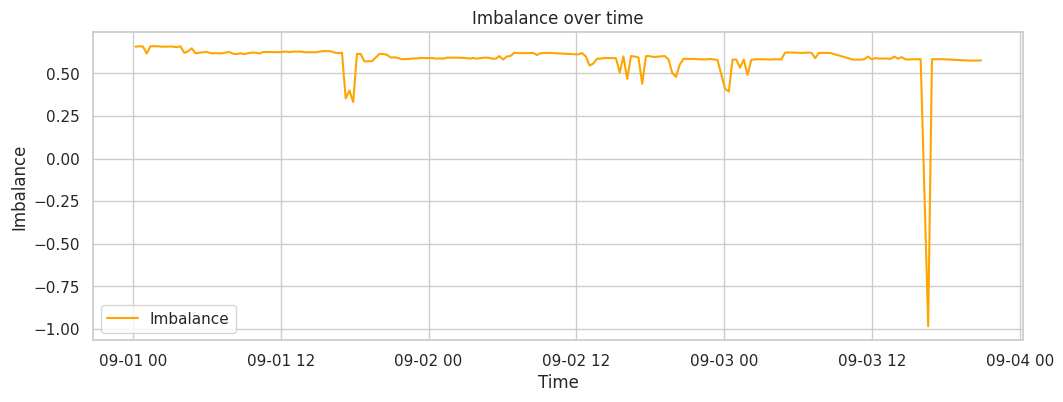

In [8]:
# 2. Imbalance over time
plt.figure(figsize=(12,4))
plt.plot(orderbooks_features['timestamp'], orderbooks_features['imbalance'], label='Imbalance', color='orange')
plt.title('Imbalance over time')
plt.ylabel('Imbalance')
plt.xlabel('Time')
plt.legend()
plt.show()


Imbalance shows whether bids > asks or vice versa; extreme values may indicate manipulative order placement.

Found the following extreme buy ts:
Series([], Name: timestamp, dtype: datetime64[ns, UTC])
Found the following extreme sell ts:
182   2025-09-03 16:33:30.943424800+00:00
Name: timestamp, dtype: datetime64[ns, UTC]


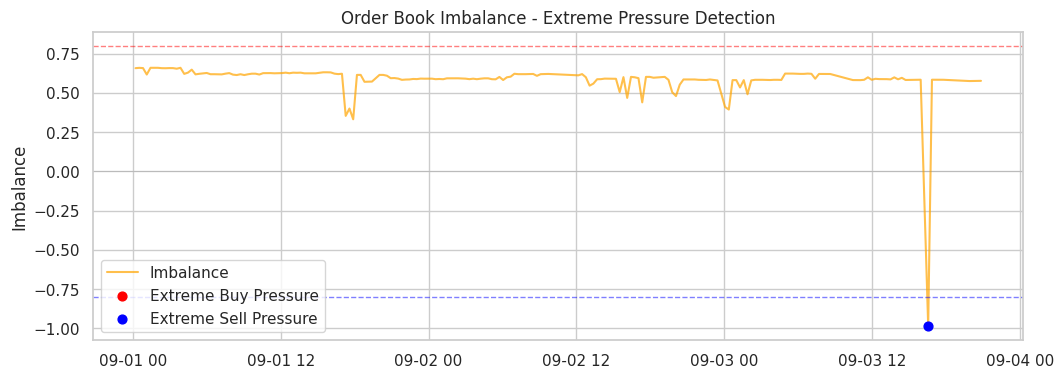

In [9]:
# Mark extreme imbalance periods
plt.figure(figsize=(12, 4))
plt.plot(orderbooks_features['timestamp'], orderbooks_features['imbalance'], label='Imbalance',color = 'orange', alpha=0.7)

# Mark extreme buy pressure (imbalance > 0.8)
extreme_buy = orderbooks_features[orderbooks_features['imbalance'] > 0.8]
plt.scatter(extreme_buy['timestamp'], extreme_buy['imbalance'], 
           color='red', s=40, label='Extreme Buy Pressure', zorder=5)
print(f"Found the following extreme buy ts:\n{extreme_buy['timestamp']}")

# Mark extreme sell pressure (imbalance < -0.8)  
extreme_sell = orderbooks_features[orderbooks_features['imbalance'] < -0.8]
print(f"Found the following extreme sell ts:\n{extreme_sell['timestamp']}")

plt.scatter(extreme_sell['timestamp'], extreme_sell['imbalance'],
           color='blue', s=40, label='Extreme Sell Pressure', zorder=5)

# Add reference lines
plt.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, linewidth=1)
plt.axhline(y=-0.8, color='blue', linestyle='--', alpha=0.5, linewidth=1)
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3, linewidth=0.5)

plt.title('Order Book Imbalance - Extreme Pressure Detection')
plt.ylabel('Imbalance')
plt.legend()
plt.show()

In [10]:
print("=== IMBALANCE ANALYSIS ===")
print(f"Extreme buy pressure (>0.8): {len(extreme_buy)} periods")
print(f"Extreme sell pressure (<-0.8): {len(extreme_sell)} periods")
print(f"Maximum buy pressure: {orderbooks_features['imbalance'].max():.2f}")
print(f"Maximum sell pressure: {orderbooks_features['imbalance'].min():.2f}")

=== IMBALANCE ANALYSIS ===
Extreme buy pressure (>0.8): 0 periods
Extreme sell pressure (<-0.8): 1 periods
Maximum buy pressure: 0.66
Maximum sell pressure: -0.98


### Imbalance Analysis Observations

**Time Period:** Sept 1-4, 2025

**Key Findings:**
- **Persistent buy-side bias** - imbalance stays above 0 for the majority of the time frame

**Suspicious Patterns:**
- ⚠️ **One trip to -0.98 on Sept 3, around 16:33** - extreme sell pressure
- ⚠️ **Sustained periods away from zero** - market often imbalanced

**Interpretation:**
- Could be a spoofing or wash-trade flush (temporary sell wall or panic moment)

**Links to spread patterns:**
- The major spread spike on Sept 2 doesn't correlate with extreme imbalance
- The trip to -0.98 doesn't seem to match with extreme spread spikes
  
> Note: These are preliminary qualitative observations. We will quantify anomalies using rolling z-scores, volume/depth ratios, and heuristic checks in the next steps

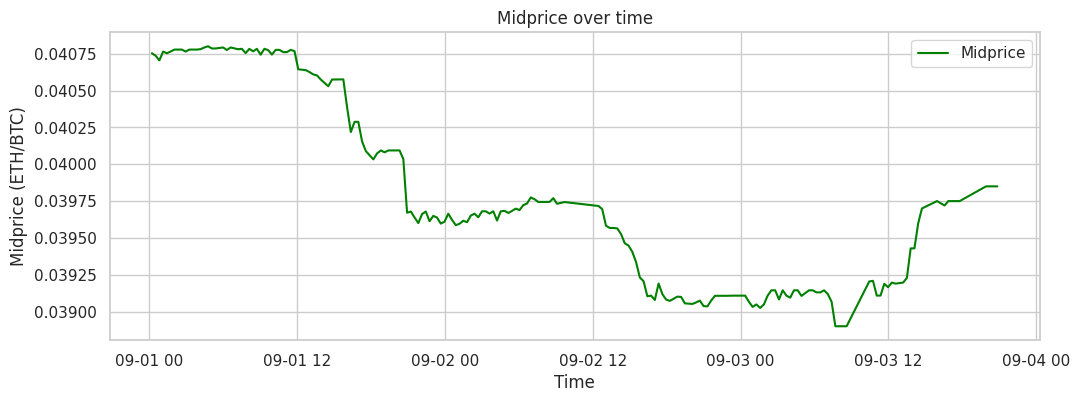

In [11]:
# 3. Midprice over time
plt.figure(figsize=(12,4))
plt.plot(orderbooks_features['timestamp'], orderbooks_features['midprice'], label='Midprice', color='green')
plt.title('Midprice over time')
plt.ylabel('Midprice (ETH/BTC)')
plt.xlabel('Time')
plt.legend()
plt.show()

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/tmp/ipykernel_13/4137213032.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(orderbooks_features['timestamp'], orderbooks_features['midprice'], 'b-', alpha=0.7, label='Midprice', color='green')


Found 4 spike up events
Found the following midprice spikes ts:
48       2025-09-01 16:03:39.064064+00:00
63    2025-09-01 20:55:54.680610400+00:00
167   2025-09-03 10:26:40.706950500+00:00
177   2025-09-03 13:48:25.567782900+00:00
Name: timestamp, dtype: datetime64[ns, UTC]


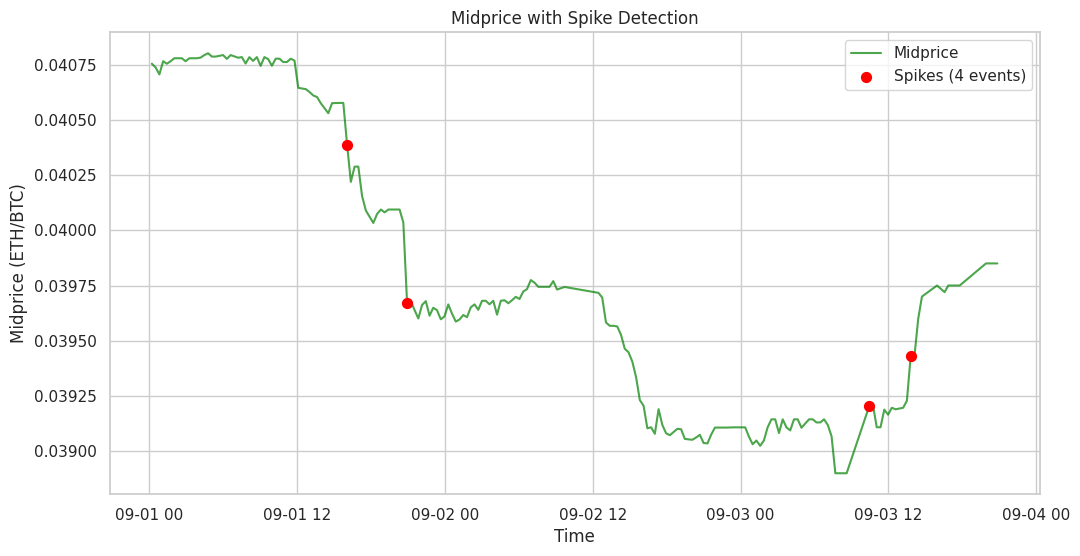

In [12]:
# Calculate the "spikiness" - how fast the price is changing ABS val!!!
orderbooks_features['midprice_change'] = orderbooks_features['midprice'].diff().abs()  # Absolute change from previous point

# Find spikes - sudden large changes
spike_threshold = orderbooks_features['midprice_change'].quantile(0.98)  # Top 2% of changes
spikes = orderbooks_features[orderbooks_features['midprice_change'] > spike_threshold]

print(f"Found {len(spikes)} spike up events")
print(f"Found the following midprice spikes ts:\n{spikes['timestamp']}")

# Plot with spikes marked
plt.figure(figsize=(12, 6))
plt.plot(orderbooks_features['timestamp'], orderbooks_features['midprice'], 'b-', alpha=0.7, label='Midprice', color='green')
plt.scatter(spikes['timestamp'], spikes['midprice'], color='red', s=50, zorder=5, 
           label=f'Spikes ({len(spikes)} events)')

plt.title('Midprice with Spike Detection')
plt.ylabel('Midprice (ETH/BTC)')
plt.xlabel('Time')
plt.legend()
plt.show()

### Midprice Analysis Observations

**Time Period:** Sept 1-4, 2025

**Key Findings:**
- **Overall trend:** Gradual downward trend 
- **Volatility level:** **MODERATE** - mostly smooth, but found 4 major spikes
- No midprice spikes around the imbalance trip to -0.98 detected

**Suspicious Patterns:**
- **Sept 1, at 16:03 and 20:55**: - major drop in price, both times match closely to spikes in spread on the same day, which happen later, at 16:40 and 21:14
- **Sept 2, after 12:00**: Midprice goes down (not as an extreme spike, but still drops), and later on that day the spread spike at 17:20 hapenned
- Sustained buy imbalance but falling prices

**Interpretation:**
- The above events suggest natural panic behaviour: price drops typically precede spread spikes → natural “panic” reaction
- Selling pressure likely organic, but the lagged spread spikes may reflect market maker retreat or temporary liquidity vacuum
- Sustained buy imbalance be deceptive — maybe orders posted but not filled (possible “fake” depth)


> Note: These are preliminary qualitative observations. We will quantify anomalies using global z-scores, volume/depth ratios, and heuristic checks in the next steps


## Quantitative anomaly detection
**Goal:** Now that I visually spotted suspicious events, I’ll check if they’re statistically unusual using the rolling z-score, because it adapts to changing markets and can detect sudden regime changes. 

**Approach:** I will calculate them for spread, imbalance and midprice change (instead of midprice itself), because this will allow me to detect sudden drops and jumps and abnormal velocity bursts. This approach normalizes deviations within short-term volatility regimes, enabling the detection of transient anomalies rather than long-term shifts. z-score of 3 is the statistical "rule of thumb" for extreme outliers.

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


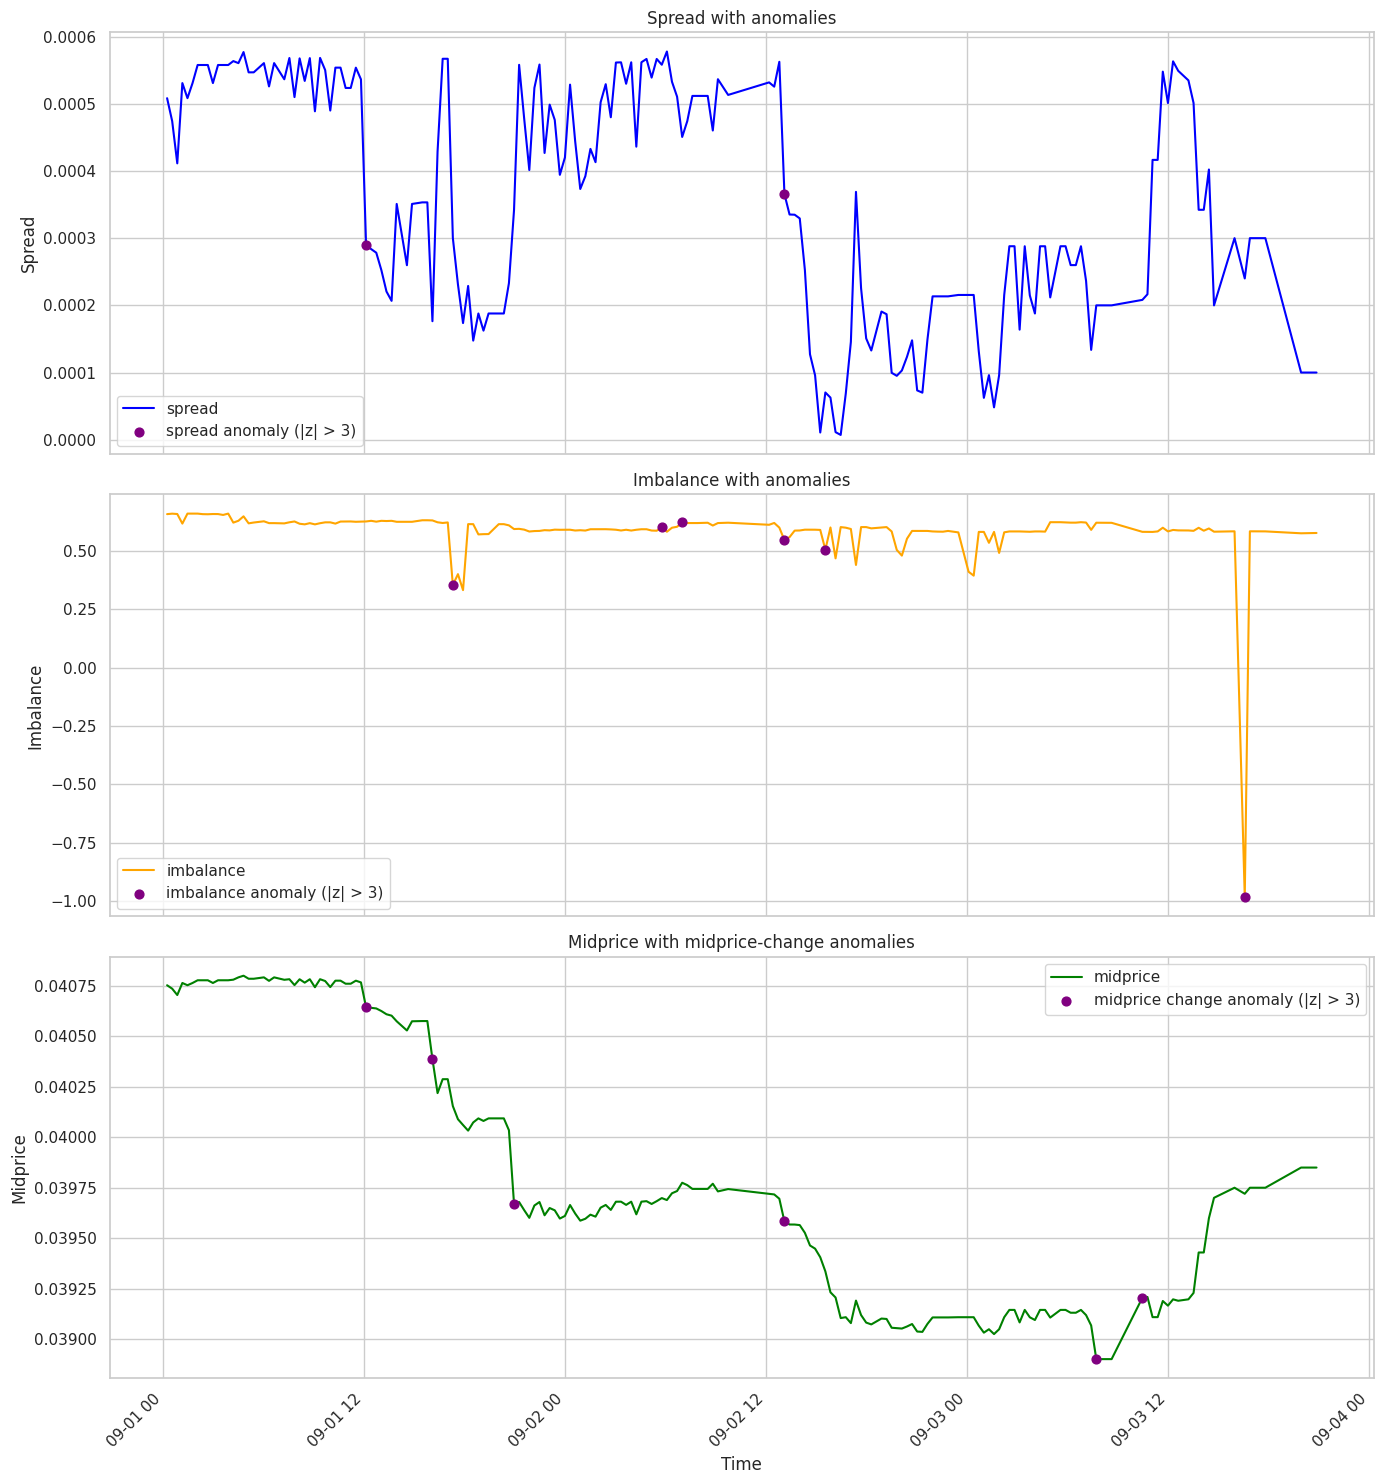

                              timestamp  midprice  midprice_change  \
37  2025-09-01 12:05:55.382923600+00:00  0.040645        -0.000123   
48     2025-09-01 16:03:39.064064+00:00  0.040388        -0.000188   
52  2025-09-01 17:16:45.945704900+00:00  0.040155        -0.000133   
63  2025-09-01 20:55:54.680610400+00:00  0.039671        -0.000364   
92  2025-09-02 05:45:13.406877100+00:00  0.039699         0.000015   
96     2025-09-02 06:58:17.354837+00:00  0.039775         0.000041   
107 2025-09-02 13:04:33.534223400+00:00  0.039583        -0.000113   
115 2025-09-02 15:31:10.867082700+00:00  0.039335        -0.000070   
164 2025-09-03 07:41:41.281392900+00:00  0.038900        -0.000167   
167 2025-09-03 10:26:40.706950500+00:00  0.039204         0.000304   
182 2025-09-03 16:33:30.943424800+00:00  0.039720        -0.000030   

     midchg_z_roll    spread  spread_z_roll  imbalance  imbalance_z_roll  
37       -3.343182  0.000290      -3.890766   0.626240          1.078306  
48       

In [13]:
df = orderbooks_features.copy()  # 
# Ensure timestamp sorted and datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)


# 1) midprice change (short-term move)
df['midprice_change'] = df['midprice'].diff()

# 2) our data is approx 20 min window, so 3 snapshots per hour
window = 20

# 3) rolling mean/std and rolling z-scores
df['spread_roll_mean'] = df['spread'].rolling(window, min_periods=5).mean()
df['spread_roll_std']  = df['spread'].rolling(window, min_periods=5).std().replace(0, np.nan)
df['spread_z_roll']    = (df['spread'] - df['spread_roll_mean']) / df['spread_roll_std']

df['midchg_roll_mean'] = df['midprice_change'].rolling(window, min_periods=5).mean()
df['midchg_roll_std']  = df['midprice_change'].rolling(window, min_periods=5).std().replace(0, np.nan)
df['midchg_z_roll']    = (df['midprice_change'] - df['midchg_roll_mean']) / df['midchg_roll_std']

df['imb_roll_mean'] = df['imbalance'].rolling(window, min_periods=5).mean()
df['imb_roll_std']  = df['imbalance'].rolling(window, min_periods=5).std().replace(0, np.nan)
df['imbalance_z_roll'] = (df['imbalance'] - df['imb_roll_mean']) / df['imb_roll_std']

# 4) flagging
z_thresh = 3.0
df['spread_anom_roll'] = df['spread_z_roll'].abs() > z_thresh
df['midchg_anom_roll'] = df['midchg_z_roll'].abs() > z_thresh
df['imbalance_anom_roll'] = df['imbalance_z_roll'].abs() > z_thresh



# 9) Quick visual: highlight rolling anomalies on your original plots
fig, axs = plt.subplots(3,1, figsize=(14,15), sharex=True)

fig.autofmt_xdate()  # Auto-format dates for readability

axs[0].plot(df['timestamp'], df['spread'], label='spread', color='blue',zorder=1)
axs[0].scatter(df.loc[df['spread_anom_roll'],'timestamp'], df.loc[df['spread_anom_roll'],'spread'],
               color='purple', s=40, label='spread anomaly (|z| > 3)', zorder=2)
axs[0].set_title('Spread with anomalies')
axs[0].set_ylabel('Spread')
axs[0].legend()

axs[1].plot(df['timestamp'], df['imbalance'], label='imbalance', color='orange', zorder=1)
axs[1].scatter(df.loc[df['imbalance_anom_roll'],'timestamp'], df.loc[df['imbalance_anom_roll'],'imbalance'],
               color='purple', s=40, label='imbalance anomaly (|z| > 3)',zorder=2)
axs[1].set_title('Imbalance with anomalies')
axs[1].set_ylabel('Imbalance')
axs[1].legend()

axs[2].plot(df['timestamp'], df['midprice'], label='midprice', color='green', zorder=1)
axs[2].scatter(df.loc[df['midchg_anom_roll'],'timestamp'], df.loc[df['midchg_anom_roll'],'midprice'],
               color='purple', s=40, label='midprice change anomaly (|z| > 3)', zorder=2)
axs[2].set_title('Midprice with midprice-change anomalies')
axs[2].set_ylabel('Midprice')
axs[2].legend()

# Simple date formatting
plt.xticks(rotation=45)
plt.xlabel('Time')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

os.makedirs('charts', exist_ok=True)
plt.xlabel('Time')
plt.tight_layout()
plt.savefig('charts/orderbook_anomalies.png', bbox_inches='tight', dpi=150)
plt.show()



# 5) a compact anomalies table
anoms = df.loc[df[['spread_anom_roll','midchg_anom_roll','imbalance_anom_roll']].any(axis=1),
               ['timestamp','midprice','midprice_change','midchg_z_roll','spread','spread_z_roll','imbalance','imbalance_z_roll']]
anoms.sort_values('timestamp', inplace=True)
print(anoms)


### Quantitative and Qualitative Analysis Links

**Key Findings:**
- Rolling z-score identified 2 spread anomalies, 6 imbalance anomalies, 6 midprice anomalies occurring between Sept 1–4, 2025.
- Spread anomalies highlighted by rolling z-score do not match with detected visual spread anomalies
- Imbalance anomaly found during the visual stage (jump to -0.98) is confirmed to be abnormal by z-score analysis -> extreme sell pressure confirmed
- 6 midprice anomalies detected using z-score of midprice change, 3 of them match with the ones noted during the preliminary visual stage
- Anomalies do not seem to be clustered in time
- Some anomalies do conincide across features, specfically:
  * Spread & midprice change on Sep 1, 12:05 : BOTH DROP
      * **Interpretation:** 
        - Liquidity unexpectedly improved while price fell
        - Suggests someone provided liquidity to execute a large sell order
        - **Suspicious**: Contradicts normal market behavior
  * Spread & imbalance & midprice change on Sep 2, 13:04 : ALL DROP
      * **Interpretation:** 
        - **Suspicious**: Could be stealth manipulation


In [14]:
# making a list of suspicious timestamps
suspicious_events = [
    # Format: (timestamp, reason)
    ('2025-09-03 16:33:30.943424800+00:00', 'imbalance spike'),
    ('2025-09-01 16:03:39.064064+00:00', 'midprice drop & spread spike'),
    ('2025-09-01 20:55:54.680610400+00:00', 'midprice drop & spread spike'),
    ('2025-09-01 12:05:55.382923600+00:00', 'spread & midprice change abnormal drop'),
    ('2025-09-02 13:04:33.534223400+00:00', 'spread & midprice change & imbalance abnormal drop')  
]

suspect_df = pd.DataFrame(suspicious_events, columns=['timestamp', 'reason'])
suspect_df['minute'] = pd.to_datetime(suspect_df['timestamp']).dt.floor('min')
suspect_df = suspect_df.sort_values('minute').reset_index(drop=True)

print("Your investigation targets:")
print(suspect_df)

Your investigation targets:
                             timestamp  \
0  2025-09-01 12:05:55.382923600+00:00   
1     2025-09-01 16:03:39.064064+00:00   
2  2025-09-01 20:55:54.680610400+00:00   
3  2025-09-02 13:04:33.534223400+00:00   
4  2025-09-03 16:33:30.943424800+00:00   

                                              reason                    minute  
0             spread & midprice change abnormal drop 2025-09-01 12:05:00+00:00  
1                       midprice drop & spread spike 2025-09-01 16:03:00+00:00  
2                       midprice drop & spread spike 2025-09-01 20:55:00+00:00  
3  spread & midprice change & imbalance abnormal ... 2025-09-02 13:04:00+00:00  
4                                    imbalance spike 2025-09-03 16:33:00+00:00  


## Applying trades and depth context
**Goal:** To decide if the anomalies were backed by real trading (volume movement) or were just an order-book only event (possible spoofing).

Depth tells us how much size was actually available. If volume greatly exceeds depth, price is easy to move. If depth disappears when spread spikes, liquidity was pulled. Even when trade volume doesn’t spike, depth anomalies reveal potential manipulative intent: spoofing, layering, or liquidity withdrawal.

In [15]:
pd.reset_option('display.max_rows')
trades = trades.sort_values('timestamp').reset_index(drop=True)

# floor to minute (or choose 'S' for second bins if high-frequency)
trades['minute'] = trades['timestamp'].dt.floor('min')

trade_min = trades.groupby('minute').agg(
    trade_price = ('price','mean'),
    trade_volume = ('size','sum'),
    trade_count = ('price','count')
).reset_index()

# prepare orderbook minute (use last snapshot in each minute)
orderbooks_features['minute'] = orderbooks_features['timestamp'].dt.floor('min')
ob_min = orderbooks_features.sort_values('timestamp').groupby('minute').last().reset_index()

# merge
merged = pd.merge(ob_min, trade_min, on='minute', how='left').fillna({'trade_volume':0,'trade_count':0})
merged[['minute','midprice','spread','imbalance','trade_volume','trade_count']]


,minute,midprice,spread,imbalance,trade_volume,trade_count
0,2025-09-01 00:13:00+00:00,0.040754,0.000508,0.657605,114.86474,1.0
1,2025-09-01 00:31:00+00:00,0.040737,0.000474,0.659644,0.00000,0.0
2,2025-09-01 00:49:00+00:00,0.040706,0.000411,0.658108,0.00000,0.0
3,2025-09-01 01:07:00+00:00,0.040765,0.000531,0.617064,131.34443,1.0
4,2025-09-01 01:26:00+00:00,0.040754,0.000508,0.659882,0.00000,0.0
...,...,...,...,...,...,...
183,2025-09-03 16:51:00+00:00,0.039750,0.000300,0.583965,0.00000,0.0
184,2025-09-03 17:29:00+00:00,0.039750,0.000300,0.583942,0.00000,0.0
185,2025-09-03 17:47:00+00:00,0.039750,0.000300,0.583664,0.00000,0.0
186,2025-09-03 19:55:00+00:00,0.039850,0.000100,0.575491,0.00000,0.0


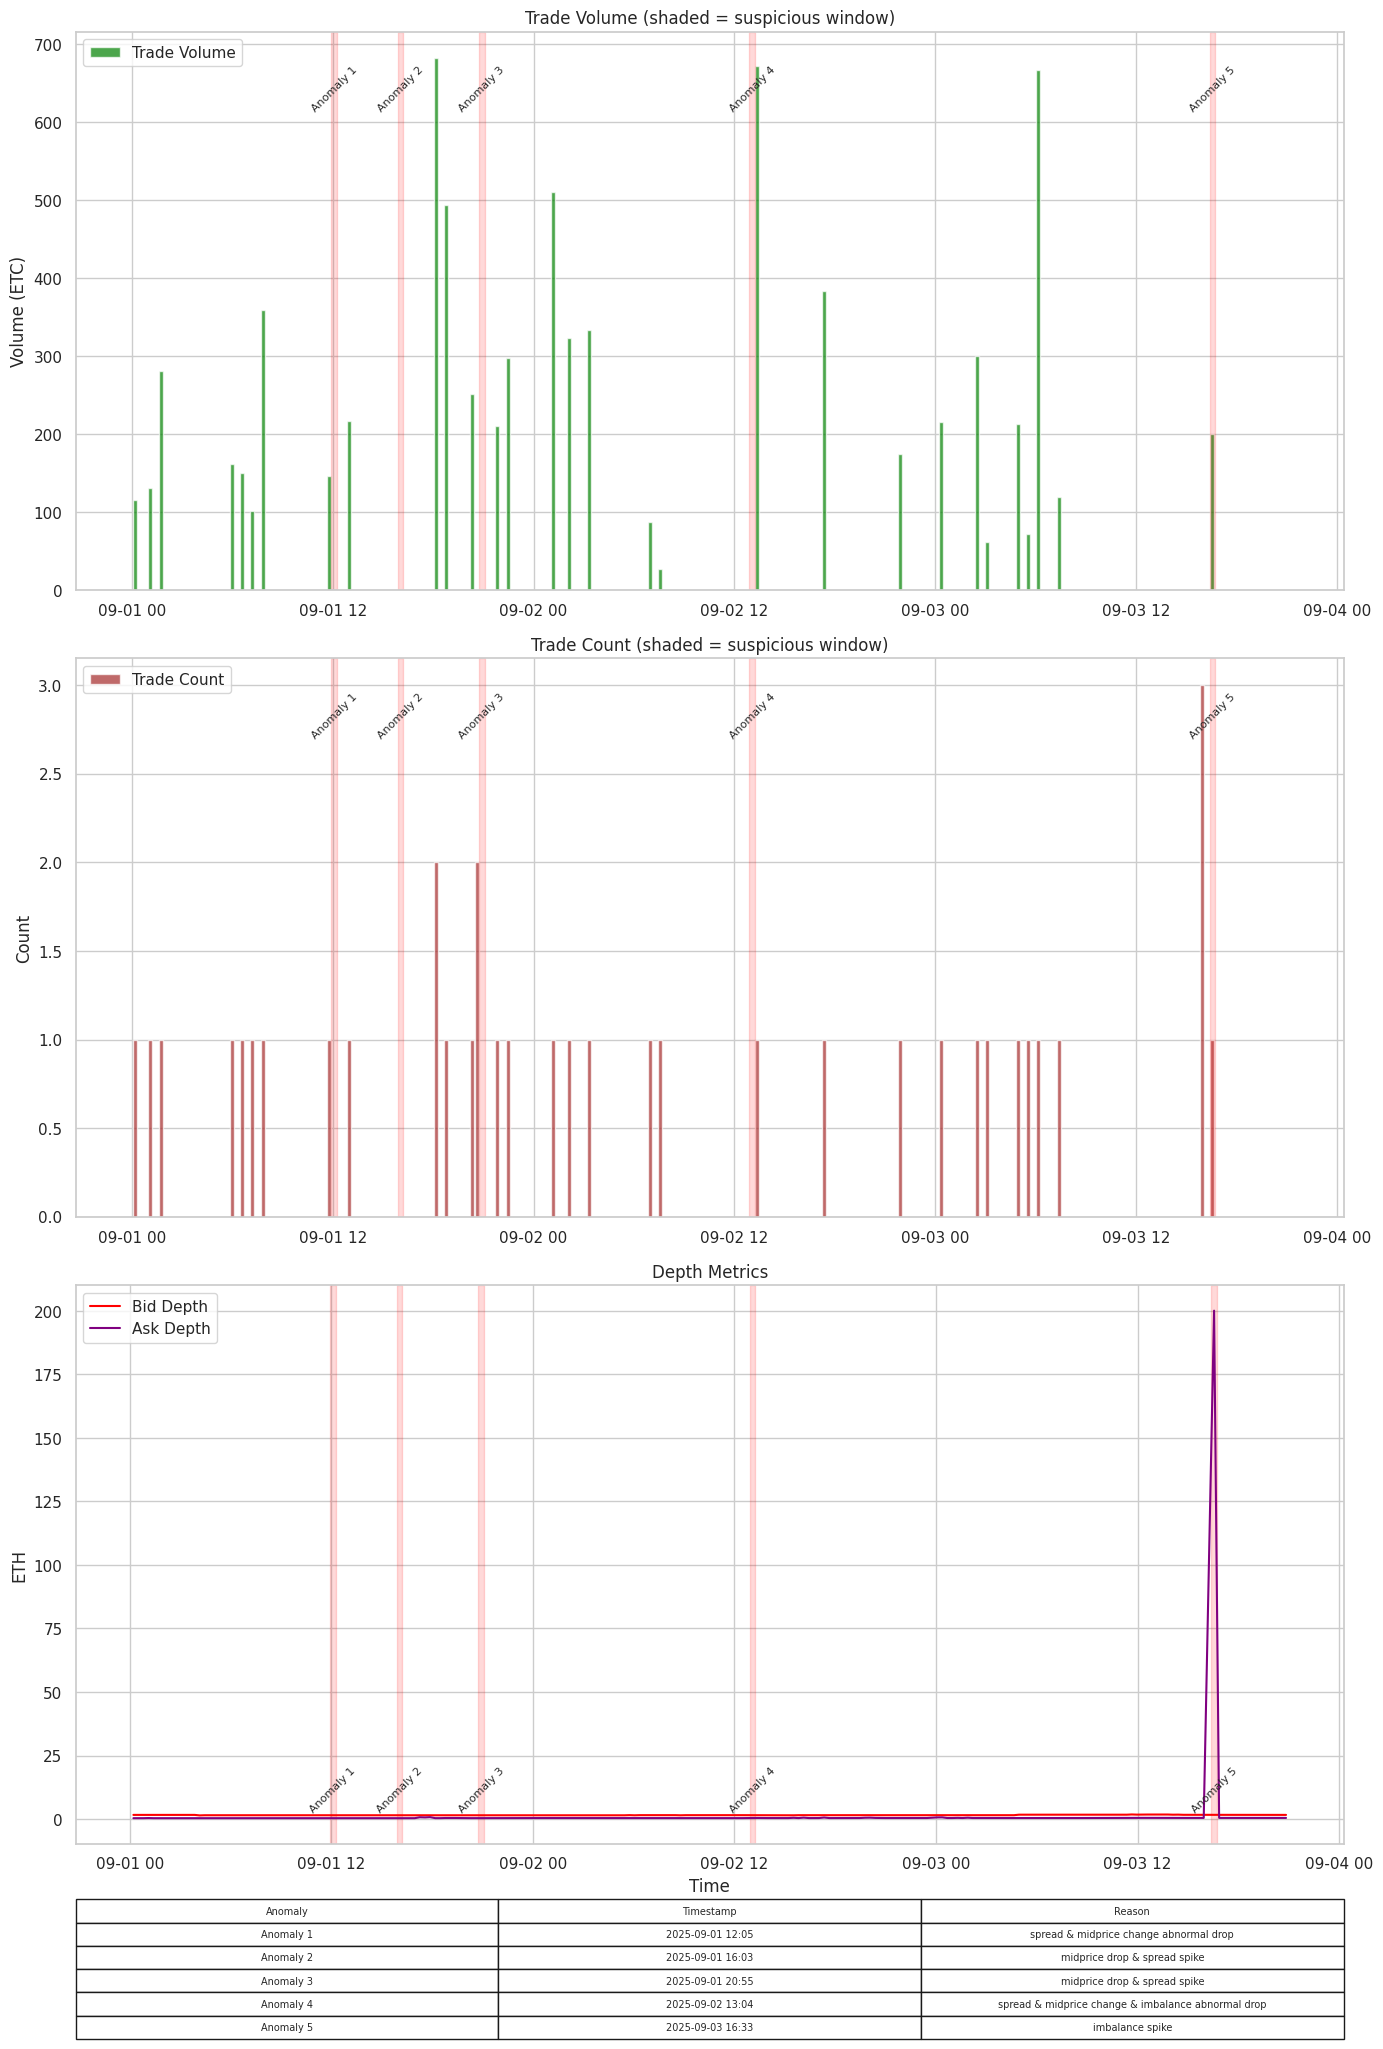

In [16]:
window = pd.Timedelta('10min')

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 20))

# -------------------------
# 1. Trade Volume Plot
# -------------------------
ax1.bar(merged['minute'], merged['trade_volume'], color='green', alpha=0.7, label='Trade Volume',  width = 0.01)

for i, event in suspect_df.iterrows():
    start = event['minute'] - window
    end = event['minute'] + window
    ax1.axvspan(start, end, color='red', alpha=0.15)
    ax1.text(event['minute'], merged['trade_volume'].max() * 0.9, 
             f"Anomaly {i+1}", rotation=45, fontsize=8, ha='center')

ax1.set_title('Trade Volume (shaded = suspicious window)')
ax1.set_ylabel('Volume (ETC)')
ax1.legend(loc='upper left')

# -------------------------
# 2. Trade Count Plot
# -------------------------
ax2.bar(merged['minute'], merged['trade_count'], color='brown', alpha=0.7, label='Trade Count',  width = 0.01)

for i, event in suspect_df.iterrows():
    start = event['minute'] - window
    end = event['minute'] + window
    ax2.axvspan(start, end, color='red', alpha=0.15)
    ax2.text(event['minute'], merged['trade_count'].max() * 0.9, 
             f"Anomaly {i+1}", rotation=45, fontsize=8, ha='center')

ax2.set_title('Trade Count (shaded = suspicious window)')
ax2.set_ylabel('Count')
ax2.legend(loc='upper left')


ax3.plot(merged['minute'], merged['bid_depth'], color='red', label='Bid Depth')
ax3.plot(merged['minute'], merged['ask_depth'], color='purple', label='Ask Depth')


for i, event in suspect_df.iterrows():
    start = event['minute'] - window
    end = event['minute'] + window
    ax3.axvspan(start, end, color='red', alpha=0.15)
    ax3.text(event['minute'], merged['trade_count'].max() * 0.9, 
             f"Anomaly {i+1}", rotation=45, fontsize=8, ha='center')

ax3.set_ylabel('ETH')
ax3.legend(loc='upper left')
ax3.set_title('Depth Metrics')
ax3.legend()

# -------------------------
# 3. Table Below Figure
# -------------------------
# Prepare table data
table_data = [[f"Anomaly {i+1}", event['minute'].strftime("%Y-%m-%d %H:%M"), event['reason']] 
              for i, event in suspect_df.iterrows()]

# Add space for table
fig.subplots_adjust(bottom=0.25)

# Add table
table = plt.table(cellText=table_data,
                  colLabels=["Anomaly", "Timestamp", "Reason"],
                  cellLoc='center',
                  colLoc='center',
                  loc='bottom',
                  bbox=[0.0, -0.35, 1, 0.25])  # [left, bottom, width, height]

# -------------------------
plt.xlabel('Time')
plt.tight_layout()
plt.savefig('charts/trade_depth_context.png', bbox_inches='tight', dpi=150)
plt.show()


### Insights from trading data
The shaded region (in a time window of 10 minutes) above corresponds to the times when the orderbook anomaly occurred (midprice/spread/imbalance spike). 
Trade volume spikes = actual trading activity that may be a market reaction. Note: Only minutes with orderbook snapshots are included; trades outside these minutes are ignored.

The relative position of spikes to shaded regions tells us what kind of market behavior might be happening.
**Key Findings:**
- **Depth** - Depth is thin throughout the time period, except for one spike. That means that market is very illiquid — few resting orders, shallow orderbook. Even small market orders can move price a lot which may explain midprice drops/spread spikes. This makes the market more vulnerable to manipulative tactics like spoofing or micro-pumps
- **Anomaly 1 - spread & midprice change abnormal drop**: Trade volume and count spike precedes the anomaly shaded region, possibly indicating that orderbook changes were a response to high trading pressure rather than manipulation
- **Anomaly 2 - midprice drop & spread spike**: Volume spike occurs independently of the flagged orderbook anomaly, suggesting normal market activity rather than manipulation
- **Anomaly 3 - midprice drop & spread spike**: Trades preceded orderbook anomaly -> same as Anomaly 1
- **Anomaly 4 - midprice drop & spread spike**: Trade volume and count spike follows the orderbook anomaly, consistent with manipulative behavior where quote changes precede execution (e.g., spoofing setup → aggressive trades)
- **Anomaly 5 - imbalance spike**: Volume spike coincides with the orderbook anomaly, suggesting immediate market reaction, possibly aggressive trading triggered by imbalance/spread changes. The orderbook exhibited an abrupt 200 ETH increase in ask-side depth, producing a sharp negative imbalance. This event coincided with elevated trade volume and count during the same minute. The simultaneous presence of large visible liquidity and active trading suggests either (a) a large sell-side execution event, where substantial resting liquidity was consumed, or (b) a transient sell-side wall that prompted follow-on selling — consistent with potential spoofing or short-term sentiment manipulation. In either case, the depth imbalance represents a clear deviation from normal orderbook behavior and likely influenced short-term price dynamics.

Not all orderbook anomalies correspond to immediate trade volume spikes. Some appear benign, while others show temporal patterns consistent with manipulative strategies such as spoofing or coordinated sell/buy pressure.


## Anomaly analysis

Out of the 5 flagged orderbook anomalies:
- 2 events (anomaly 4 and 5) were accompanied by significant trade volume spikes, suggesting potential manipulative activity (e.g., coordinated buying or selling).  
- 3 events showed orderbook irregularities without corresponding volume changes, indicating either benign fluctuations or unsuccessful attempts at market manipulation.

**Anomalies 1,2,3 — Spread & midprice anomalies**

* Description: Midprice change dropped while spread widened - both in the top 2% of changes.

* Context: Trade volume exists minutes before and after anomaly.

* Depth: Both bid and ask depth < 2 ETH.

* Interpretation: Indicates genuine market pressure rather than manipulation — orderbook widened in response to active trading.

* Evidence rating: 🔹 Low — consistent with normal trading.


**Anomaly 4 — Spread & midprice & imbalance anomalies (2025-09-02 13:04 UTC)**

* Description: Spread widenedwith midprice falling and imbalance dropping - all in the top 2% of changes and indicated by z-score as anomalous.

* Context: Significant trade volume exists minutes after anomaly.

* Depth: Both bid and ask depth < 2 ETH.

* Interpretation: Quotes changed before trades — consistent with spoofing setup or liquidity pull-back preceding aggressive orders.

* Evidence rating: 🔺 Strong — behavior fits manipulative timing pattern.


**Anomaly 5 — Extreme depth imbalance spike (2025-09-03 16:33 UTC)**

* Description: Ask depth jumped from 0.3 → 200 ETH; imbalance turned sharply negative

* Context: Same minute shows elevated trade volume (200 ETH).

* Depth: Sudden, isolated ask wall.

* Interpretation: An abrupt 200 ETH ask appeared, coinciding with 200 ETH of executed trades in the same minute. Since the trade volume matches the displayed depth, this appears to be a large sell-side execution rather than a spoofing attempt. The subsequent return of orderbook depth to low levels (normal for this time period) reflects the completion of this trade.

* Evidence rating: 🔹 Low — consistent with normal trading.

# Stage 2: Macro-level heuristics

**Goal:** Aggregate heuristics to look for broader suspicious trading patterns

## Abnormal volume spikes
**Goal:** Detect trades where volume is unusually high compared to typical market activity.

In [17]:
# Ensure trades are sorted and have side encoded as +1 for BUY, -1 for SELL
trades = trades.sort_values('timestamp').reset_index(drop=True)
trades['side_flag'] = trades['side'].apply(lambda x: 1 if x=='BUY' else -1)

In [18]:
trades
# Aggregate trade volume per minute
volume_minute = trades.groupby('minute')['size'].sum().reset_index(name='trade_volume')

# Compute rolling mean & std
window = 20  # 20-minute rolling window
volume_minute['vol_mean'] = volume_minute['trade_volume'].rolling(window, min_periods=1).mean()
volume_minute['vol_std'] = volume_minute['trade_volume'].rolling(window, min_periods=1).std()

# Z-score of volume
volume_minute['vol_zscore'] = (volume_minute['trade_volume'] - volume_minute['vol_mean']) / (volume_minute['vol_std'] + 1e-9)

# Flag spikes > 2σ
volume_minute['volume_spike'] = volume_minute['vol_zscore'] > 2

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


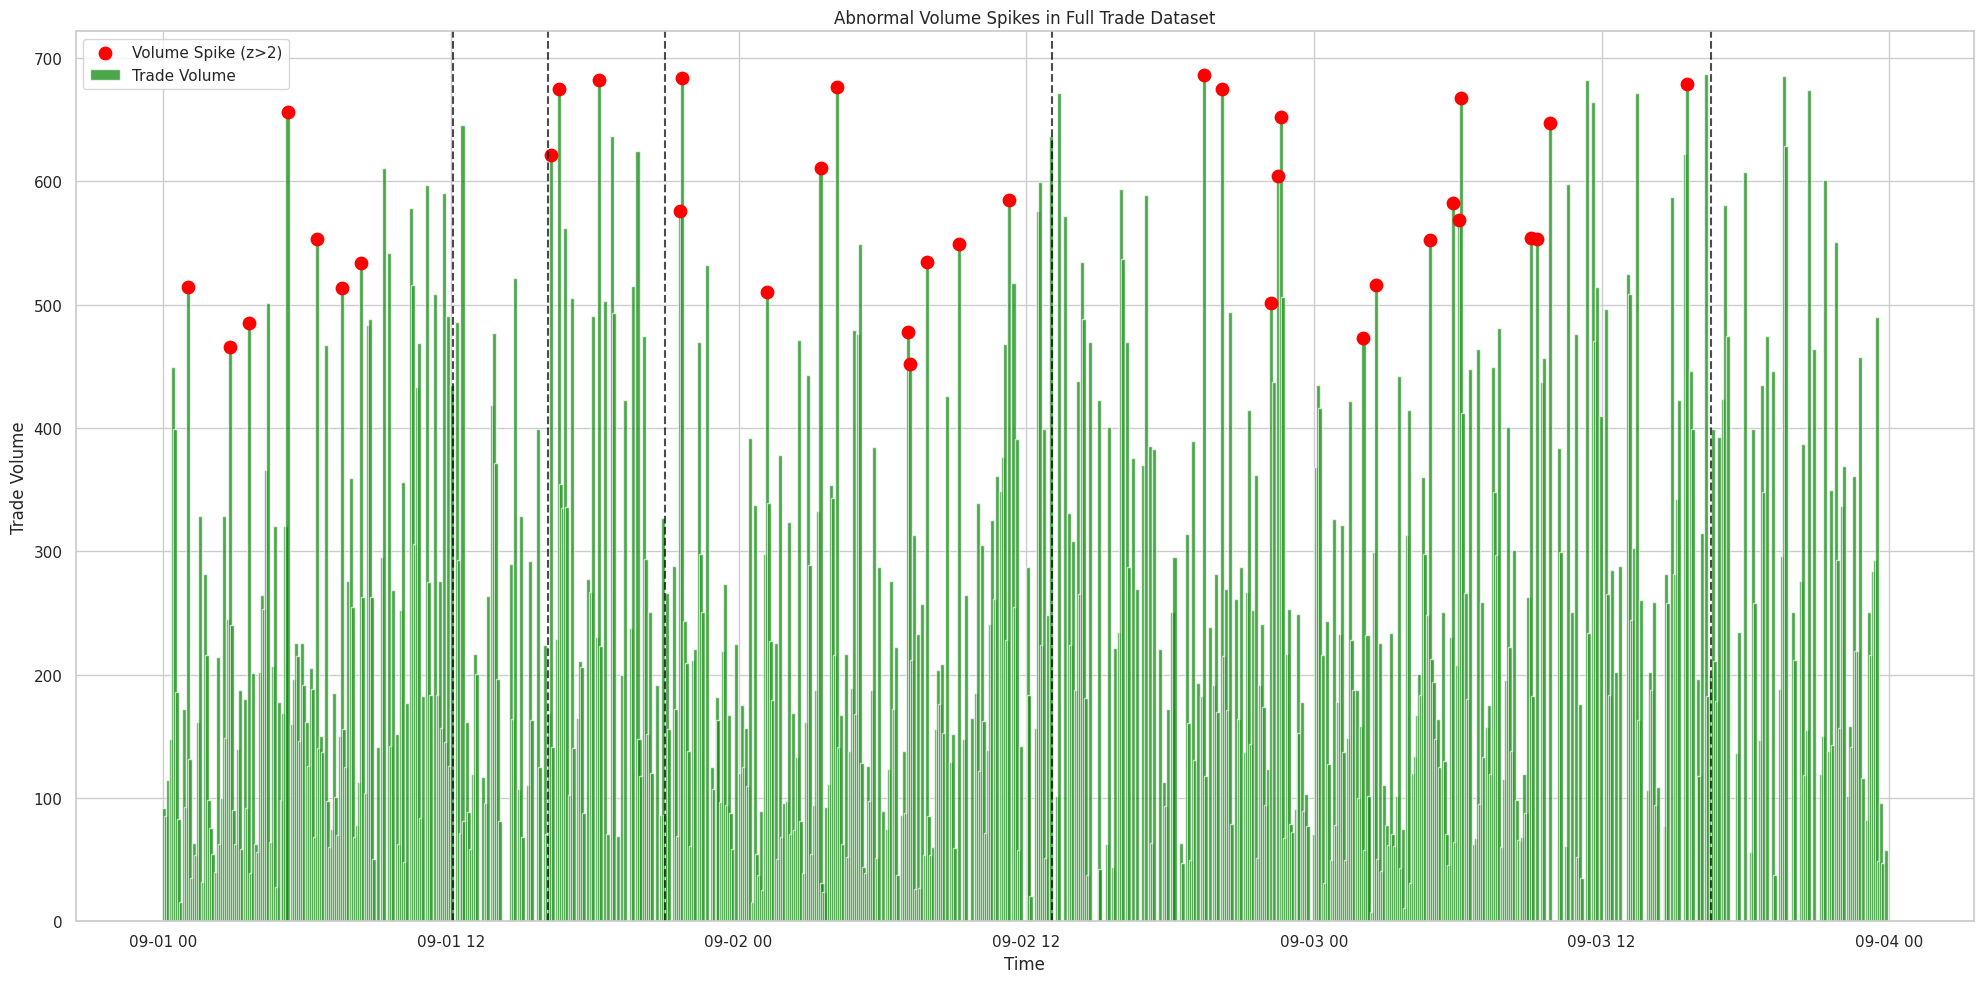

Found 35 abnormal trading volume spikes


In [19]:
import matplotlib.pyplot as plt

# STEP 1: Prepare data (assuming you already computed this)
# volume_minute['trade_volume'], 'vol_zscore', 'volume_spike'

fig, ax = plt.subplots(figsize=(20,10))

# Plot trade volume
ax.bar(volume_minute['minute'], volume_minute['trade_volume'], color='green', alpha=0.7, label='Trade Volume', width = 0.007)

# Highlight abnormal volume spikes
spike_minutes = volume_minute[volume_minute['volume_spike']]['minute']
spike_volumes = volume_minute[volume_minute['volume_spike']]['trade_volume']
ax.scatter(spike_minutes, spike_volumes, color='red', marker='o', s=80, label='Volume Spike (z>2)')

# overlay micro anomalies
for ts, reason in suspicious_events:
    ax.axvline(pd.to_datetime(ts), color='black', linestyle='--', alpha=0.7, zorder=2)
    ax.text(pd.to_datetime(ts), volume_minute['trade_volume'].max()*0.95, '', rotation=45, fontsize=8, zorder=3)

ax.set_title('Abnormal Volume Spikes in Full Trade Dataset')
ax.set_xlabel('Time')
ax.set_ylabel('Trade Volume')
ax.legend()
plt.tight_layout()
plt.savefig('charts/volume_spikes.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Found {len(volume_minute[volume_minute['volume_spike']]['minute'])} abnormal trading volume spikes")


## Pump-and-Dump / Price Swings

**Goal:** Detect rapid price increases followed by decreases (or vice versa).

Consecutive pumps/dumps within a short window may indicate pump-and-dump cycles.

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/tmp/ipykernel_13/2575408811.py:67: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_ticks = pd.date_range(start=start_time.floor('H'),
/tmp/ipykernel_13/2575408811.py:68: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end=end_time.ceil('H'),


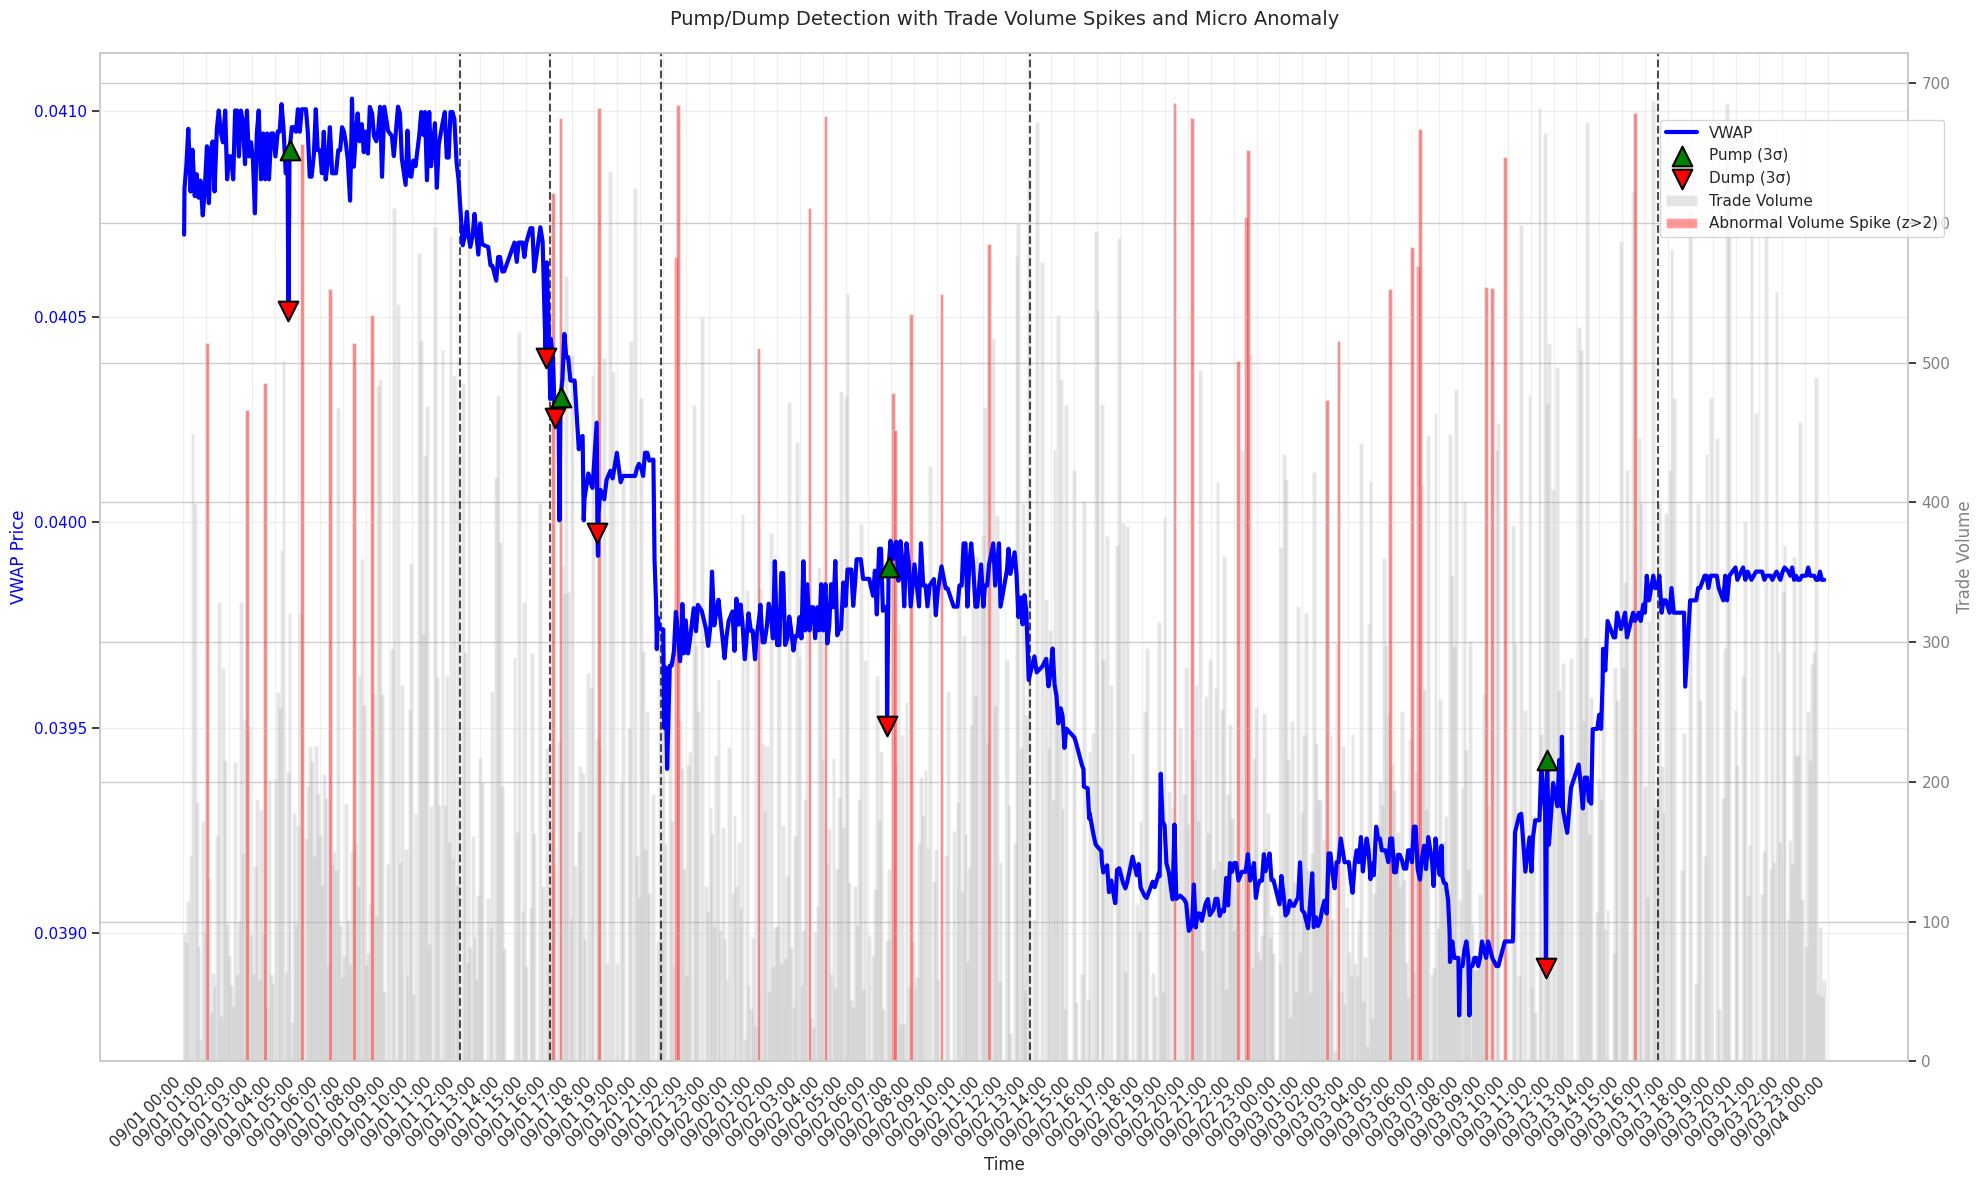

Pump events: 4, Dump events: 6


In [20]:
minute_stats = trades.groupby('minute').agg(
    price_open=('price','first'),
    price_close=('price','last'),
    price_low=('price','min'),
    price_high=('price','max'),
    volume=('size','sum'),
    trade_count=('price','count')
).reset_index()

# --- Step 2: Compute minute-to-minute returns ---
minute_stats['return'] = minute_stats['price_close'].pct_change()

# --- Step 3: Dynamic threshold (3 std deviations) ---
return_threshold = 3 * minute_stats['return'].std()
minute_stats['pump'] = minute_stats['return'] > return_threshold
minute_stats['dump'] = minute_stats['return'] < -return_threshold

# --- Step 4: Merge volume_minute to ensure alignment (optional) ---
minute_stats = pd.merge(minute_stats, volume_minute[['minute','trade_volume','volume_spike']], on='minute', how='left')

# --- Step 5: Plot VWAP price, volume, and highlight anomalies ---
fig, ax1 = plt.subplots(figsize=(20,12))

# Volume bars on secondary axis (BACKGROUND - faded)
ax2 = ax1.twinx()
ax2.set_zorder(1)  # Lower zorder for the whole axis
ax1.set_zorder(2)  # Higher zorder for the main axis
ax1.patch.set_visible(False)  # Make ax1 background transparent
ax2.bar(minute_stats['minute'], minute_stats['trade_volume'], 
        width=0.007, alpha=0.2, color='grey', label='Trade Volume', zorder=1)
# Highlight abnormal spikes (BACKGROUND - faded)
ax2.bar(minute_stats[minute_stats['volume_spike']]['minute'], 
        minute_stats[minute_stats['volume_spike']]['trade_volume'], 
        width=0.007, alpha=0.4, color='red', label='Abnormal Volume Spike (z>2)', zorder=1)
ax2.set_ylabel('Trade Volume', color='grey')
ax2.tick_params(axis='y', labelcolor='grey')

# VWAP line (FOREGROUND - prominent)
ax1.plot(minute_stats['minute'], (minute_stats['price_open'] + minute_stats['price_close'])/2, 
         color='blue', label='VWAP', linewidth=3, zorder=3)
ax1.set_ylabel('VWAP Price', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Pump/Dump markers (FOREGROUND - prominent)
ax1.scatter(minute_stats[minute_stats['pump']]['minute'], 
            (minute_stats[minute_stats['pump']]['price_open'] + minute_stats[minute_stats['pump']]['price_close'])/2,
            color='green', marker='^', s=200, label='Pump (3σ)', zorder=4, edgecolors='black', linewidth=1.5)
ax1.scatter(minute_stats[minute_stats['dump']]['minute'], 
            (minute_stats[minute_stats['dump']]['price_open'] + minute_stats[minute_stats['dump']]['price_close'])/2,
            color='red', marker='v', s=200, label='Dump (3σ)', zorder=4, edgecolors='black', linewidth=1.5)

# Overlay micro anomalies
for ts, reason in suspicious_events:
    ax1.axvline(pd.to_datetime(ts), color='black', linestyle='--', alpha=0.7, zorder=2)
    ax1.text(pd.to_datetime(ts), minute_stats['trade_volume'].max()*0.95, '', rotation=45, fontsize=8, zorder=3)

# Improve x-axis formatting for better time breakdown
ax1.set_xlabel('Time', fontsize=12)

# Set better x-axis ticks - show hours and minutes
if len(minute_stats) > 0:
    # Get the time range
    start_time = minute_stats['minute'].min()
    end_time = minute_stats['minute'].max()
    
    # Create hourly ticks
    hourly_ticks = pd.date_range(start=start_time.floor('H'), 
                                end=end_time.ceil('H'), 
                                freq='H')
    
    # Set major ticks (hours)
    ax1.set_xticks(hourly_ticks)
    
    # Format x-axis labels to show hours and minutes
    if (end_time - start_time).total_seconds() <= 86400:  # If within 24 hours
        ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))
        # Add minor ticks for every 15 minutes
        ax1.xaxis.set_minor_locator(plt.matplotlib.dates.MinuteLocator(interval=15))
    else:
        # For longer periods, show date and time
        ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%m/%d %H:%M'))
    
    # Rotate x-axis labels for better readability
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# Add grid for better readability
ax1.grid(True, alpha=0.3, zorder=0)
ax1.grid(True, which='minor', alpha=0.1, zorder=0)

# Legend and title
fig.legend(loc='upper right', bbox_to_anchor=(0.98,0.9))
plt.title('Pump/Dump Detection with Trade Volume Spikes and Micro Anomaly', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('charts/volume_spikes_pumpdump.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Pump events: {minute_stats['pump'].sum()}, Dump events: {minute_stats['dump'].sum()}")

**Observed situations:**
- 4 Pump events using dynmaic thresholds (return exceeds 3σ)

- 6 Dump events detected using dynmaic thresholds (return exceeds 3σ)

| Situation                                                   | Observed in the graph                                   | Classification / Interpretation                                                                                                                     |
| ----------------------------------------------------------- | -------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------- |
| Pump/Dump aligns with abnormal trading volume                              | Some green/red triangles coincide with red volume spikes (**e.g. Sep 2, 7:00)** | Likely **coordinated price move**; could be **micro-pump or short-term manipulation**. Volume confirms market activity behind the move.             |
| Orderbook anomaly (from step 1) near pump/dump and volume spike | Black dashed line close to a red bar or triangle (**e.g. Sep 1, 16:00)** | Consistent with potential manipulative behavior. |
| Micro anomaly with no red bar or pump/dump nearby           | Only black dashed line     **(e.g. Sep 2, 14:00)**                             | Likely **benign orderbook fluctuation**, or minor liquidity irregularity. No strong evidence of manipulative behavior.                              |
| Red volume spike with no pump/dump                          | High volume, no corresponding extreme return      **(e.g. Sep 2, 23:00)**       | Could be **normal market participation**, or potential **wash trading** if repeated in patterns. Needs further investigation.                       |
| Pump/Dump with no red bar                                   | Price moved rapidly, volume low     **(e.g. Sep 1, 5:00)**                       | Thin liquidity → even small trades move price; less likely coordinated manipulation, more likely **market sensitivity**.                            |

**Key Insights:**

**Event: Anomaly 4 — Spread & midprice & imbalance anomalies (2025-09-02 13:04 UTC)**
- High-volume activity and pump/dump not linked to suspicous orderbook anomaly #4

**Interpretation:**
- could be a manipulative setup (spoofing, thin liquidity reaction), but no strong execution evidence.


**Event: Anomaly #2 — Midprice drop & Spread Spike (2025-09-01 16:03 UTC)**

Observation:

- Orderbook anomaly: Midprice dropped, spread widened

- Price action: Small pump/dump movement observed nearby in time (minute-level returns exceeded 3σ).

**Interpretation:**

The sequence of events — orderbook irregularity → volume spike → rapid price movement — is consistent with potential manipulative behavior:

* Spoofing or liquidity pull-back: Abrupt changes in quotes may have signaled or triggered aggressive trading.

* Market reaction: Traders may have executed trades immediately after the visible imbalance.

* Short-term price impact: Coinciding pump/dump indicates the anomaly may have contributed to a brief price move.

**Classification:** 

**Moderately suspicious** — strong evidence that the orderbook event influenced short-term trading activity, but cannot conclusively prove coordinated manipulation.

## Buy/Sell Imbalance
**Goal**: Identify imbalance to mark sudden dominance of buys or sells, which often signals:

- Coordinated buying/selling pressure (e.g., part of pump or dump)

- Fake liquidity — traders placing lots of small one-sided orders to move market sentiment

/tmp/ipykernel_13/1068394247.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  imbalance_df = trades.groupby('minute').apply(
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)


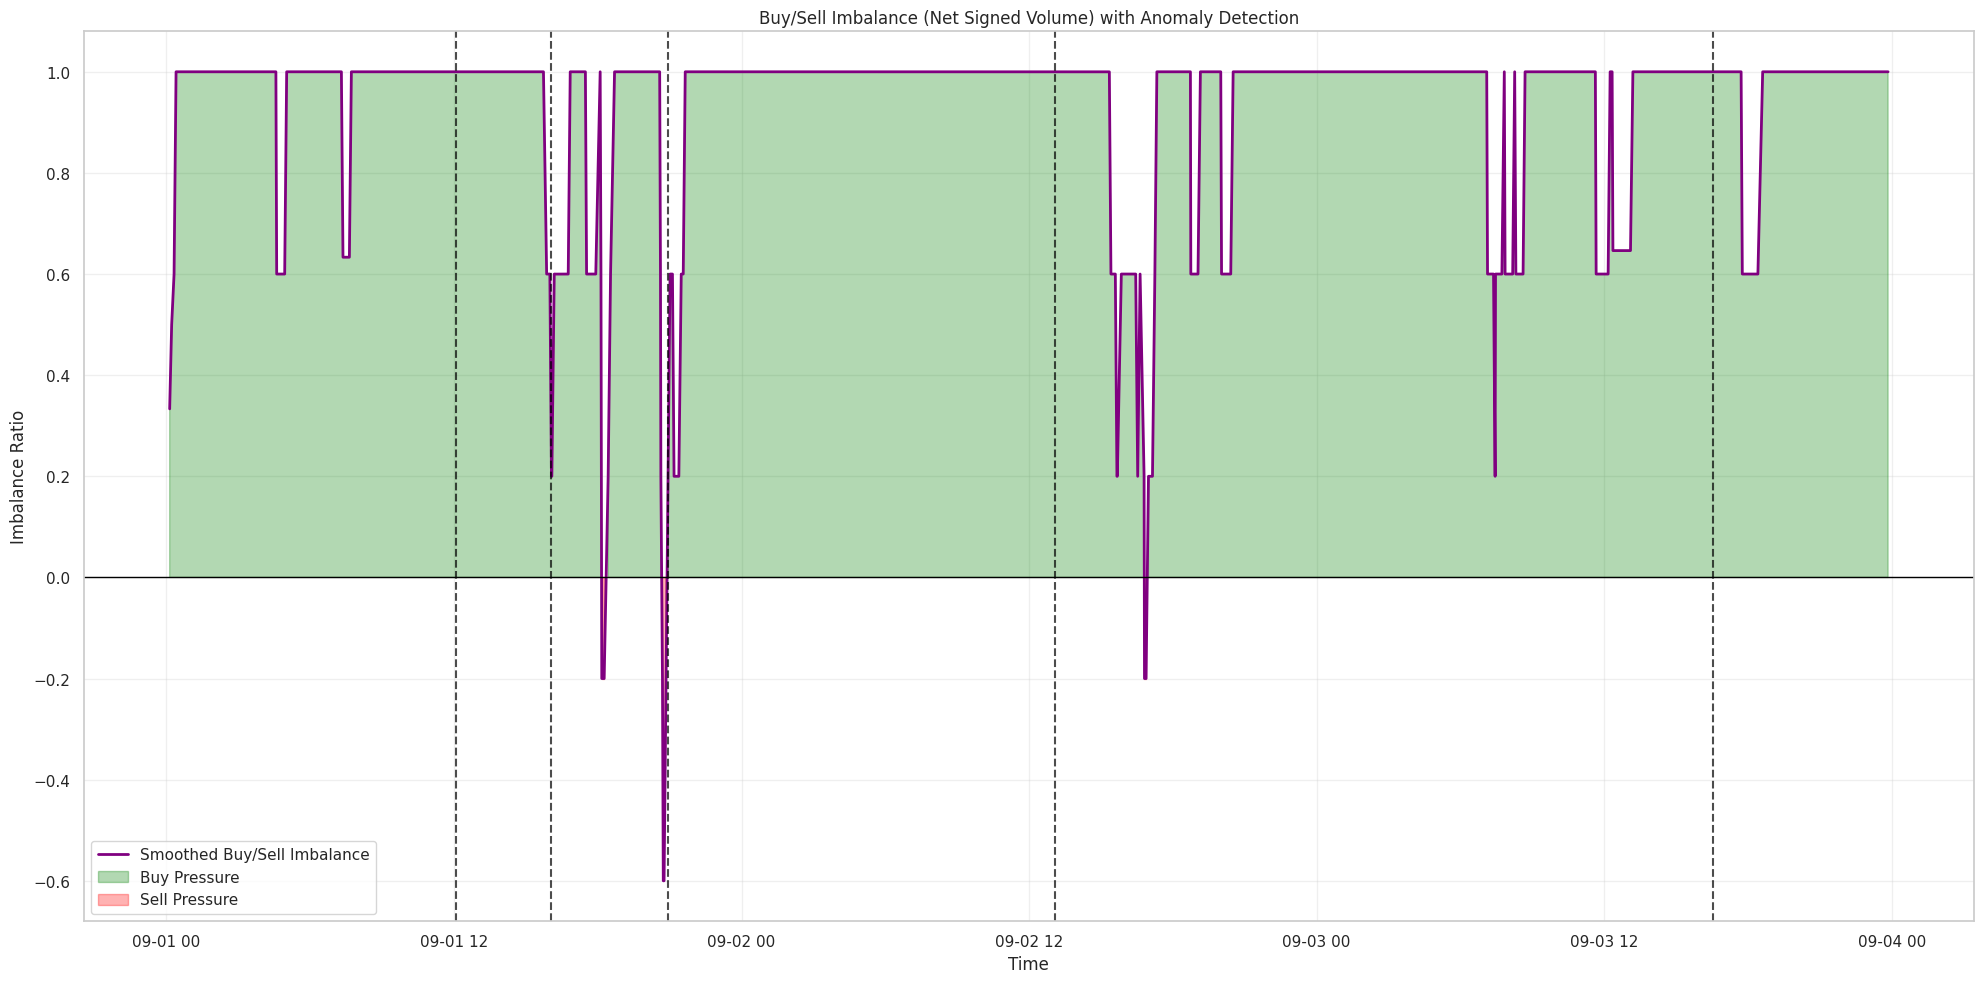

In [21]:
# Aggregate net signed volume per minute
imbalance_df = trades.groupby('minute').apply(
    lambda x: (x['size'] * x['side_flag']).sum()
).reset_index(name='net_signed_volume')

# Compute total absolute volume for normalization
total_vol = trades.groupby('minute')['size'].sum().reset_index(name='total_volume')
imbalance_df = imbalance_df.merge(total_vol, on='minute', how='left')
imbalance_df['imbalance_ratio'] = imbalance_df['net_signed_volume'] / (imbalance_df['total_volume'] + 1e-9)

# Smooth with rolling mean
imbalance_df['imbalance_smooth'] = imbalance_df['imbalance_ratio'].rolling(5, min_periods=3).mean()

# Visualize
plt.figure(figsize=(20,10))
plt.plot(imbalance_df['minute'], imbalance_df['imbalance_smooth'], label='Smoothed Buy/Sell Imbalance', color='purple', linewidth=2)
plt.axhline(0, color='black', linewidth=1)

# Add anomaly vertical lines
for ts, reason in suspicious_events:
    plt.axvline(pd.to_datetime(ts), color='black', linestyle='--', alpha=0.7, linewidth=1.5)
    plt.text(pd.to_datetime(ts), imbalance_df['imbalance_smooth'].max() * 0.9, 
             '', rotation=45, fontsize=8, ha='right', va='top')

plt.fill_between(imbalance_df['minute'], imbalance_df['imbalance_smooth'], 0,
                 where=(imbalance_df['imbalance_smooth'] > 0),
                 color='green', alpha=0.3, label='Buy Pressure')
plt.fill_between(imbalance_df['minute'], imbalance_df['imbalance_smooth'], 0,
                 where=(imbalance_df['imbalance_smooth'] < 0),
                 color='red', alpha=0.3, label='Sell Pressure')
plt.title('Buy/Sell Imbalance (Net Signed Volume) with Anomaly Detection')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Imbalance Ratio')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/buy_sell_imbalance.png', bbox_inches='tight', dpi=150)
plt.show()

In [22]:
imb = imbalance_df['imbalance_smooth']

summary = {
    'mean_imbalance': imb.mean(),
    'std_imbalance': imb.std(),
    'time_buy_dominated_%': (imb > 0.5).mean() * 100,
    'time_sell_dominated_%': (imb < -0.5).mean() * 100
}
summary


{'mean_imbalance': 0.9148054453002578,
 'std_imbalance': 0.22100750220402263,
 'time_buy_dominated_%': 96.11111111111111,
 'time_sell_dominated_%': 0.2777777777777778}

### Insights
**Observations:**
- Sustained buy-side dominance, with brief bursts of sell-side pressure
- The buy/sell imbalance remains strongly positive (~+1) for most of the period, indicating persistent buy-side pressure — the majority of trades are buyer-initiated
- Some minor dips to ~0.6 occur, showing short-lived reductions in buy dominance but not full reversals
- Deeper drops to ~0.2 coincide with Anomaly #2 (midprice drop & spread spike)
- 3 instances of negative imbalance (sell dominance) appear; one of them aligns with Anomaly #3 (midprice drop & spread spike)

**Interpretation:**

- The overall persistent buy-side dominance suggests an accumulation phase or sustained bullish activity — possibly coordinated buying behavior.

- The dips to 0.2 during Anomaly #2 imply a temporary weakening of buy pressure just as prices fell, consistent with momentary liquidity withdrawal or mild selling pressure.

- The rare negative imbalance events reflect short bursts of sell-side aggression, possibly marking localized profit-taking or dump events.

- The timing overlap between Anomaly #2 and #3 and the imbalance shifts indicates that some orderbook anomalies align with real trade flow pressure, rather than purely structural noise.


The trade flow imbalance is heavily skewed toward buyers, punctuated by brief sell-side reversals that coincide with certain orderbook anomalies.
This pattern may reflect a coordinated accumulation followed by tactical sell bursts — a possible precursor or microstructure footprint of pump-and-dump dynamics.

## Rapid alternating trades (Wash Trading)
**Goal:** 
To find unnatural, high-frequency alternation between BUY/SELL in the same short window.

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)


⚙️ Total trades: 845
⚙️ Rapid alternating trades (<5s apart): 5


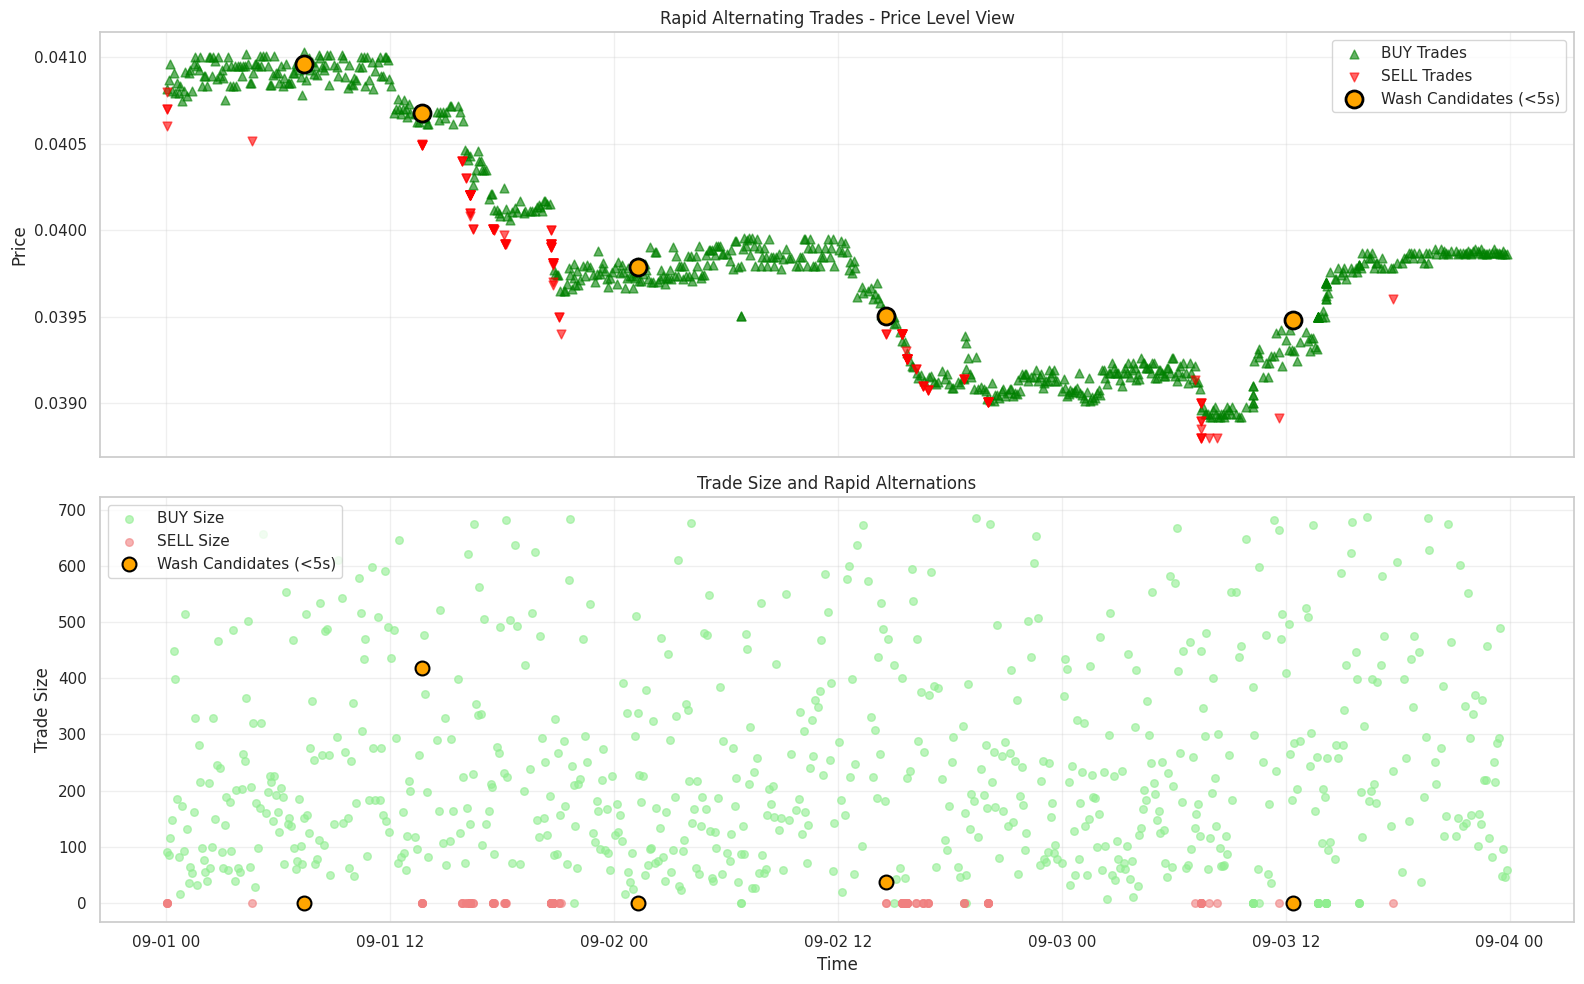


🔹 Alternation Frequency: 0.59%
🔹 Coefficient of Variation (trade size): 2.01

🟢 Low likelihood of wash trading — normal market activity.


In [23]:
# --- STEP 1: Prepare trades data ---
trades = trades.sort_values('timestamp').reset_index(drop=True)
buy_trades = trades[trades['side'] == 'BUY']
sell_trades = trades[trades['side'] == 'SELL']

# --- STEP 2: Identify rapid alternating trades ---
short_gap = 5  # seconds
trades['side_flag'] = trades['side'].apply(lambda x: 1 if x == 'BUY' else -1)
trades['time_diff'] = trades['timestamp'].diff().dt.total_seconds()
trades['side_change'] = trades['side_flag'].diff().abs()  # 2 if BUY→SELL or SELL→BUY

# Flag "wash" candidates — buy/sell flips <5s apart
wash_candidates = trades[(trades['side_change'] == 2) & (trades['time_diff'] < short_gap)]

print(f"⚙️ Total trades: {len(trades)}")
print(f"⚙️ Rapid alternating trades (<{short_gap}s apart): {len(wash_candidates)}")

# --- STEP 3: Visualization ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Price plot with buy/sell markers
ax1.scatter(buy_trades['timestamp'], buy_trades['price'], 
           color='green', alpha=0.6, s=40, label='BUY Trades', marker='^')
ax1.scatter(sell_trades['timestamp'], sell_trades['price'], 
           color='red', alpha=0.6, s=40, label='SELL Trades', marker='v')
ax1.scatter(wash_candidates['timestamp'], wash_candidates['price'],
           color='orange', s=150, edgecolors='black', linewidth=2,
           label=f'Wash Candidates (<{short_gap}s)', zorder=5)

ax1.set_title('Rapid Alternating Trades - Price Level View')
ax1.set_ylabel('Price')
ax1.legend()
ax1.grid(alpha=0.3)

# Trade size plot
ax2.scatter(buy_trades['timestamp'], buy_trades['size'], 
           color='lightgreen', alpha=0.6, s=30, label='BUY Size')
ax2.scatter(sell_trades['timestamp'], sell_trades['size'], 
           color='lightcoral', alpha=0.6, s=30, label='SELL Size')
ax2.scatter(wash_candidates['timestamp'], wash_candidates['size'],
           color='orange', s=100, edgecolors='black', linewidth=1.5,
           label=f'Wash Candidates (<{short_gap}s)', zorder=5)

ax2.set_title('Trade Size and Rapid Alternations')
ax2.set_ylabel('Trade Size')
ax2.set_xlabel('Time')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('charts/wash_trading.png', bbox_inches='tight', dpi=150)
plt.show()

# --- STEP 4: Quantitative assessment ---
alternation_rate = len(wash_candidates) / len(trades)
print(f"\n🔹 Alternation Frequency: {alternation_rate:.2%}")

if len(wash_candidates) > 2:
    cv = wash_candidates['size'].std() / wash_candidates['size'].mean()
    print(f"🔹 Coefficient of Variation (trade size): {cv:.2f}")
else:
    print("🔹 Insufficient wash candidates to compute size variability.")

# --- STEP 5: Interpretation ---
if alternation_rate < 0.05:
    print("\n🟢 Low likelihood of wash trading — normal market activity.")
elif alternation_rate < 0.10:
    print("\n🟡 Moderate likelihood — further monitoring recommended.")
else:
    print("\n🔴 High likelihood — strong wash trading signals detected.")
